<a href="https://colab.research.google.com/github/Kovalivska/Python/blob/Study/Copy_of_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In the first part we will demonstrate how Prophet uses the linear regression to find the coefficients to model seasonality



Fourier Series
===
Function
---
$$f(x) = \begin{cases}
1 & \text{for } 0<x\leq 1\\
-1 & \text{for } 1 <x \leq 2
\end{cases}
$$


Coefficients
---
General formula
$$f(x) = a_0 + \sum_{n=1}^{\infty}\Big[ a_n\cos\Big(\frac{2\pi n x}{P}\Big) + b_n\sin\Big(\frac{2\pi n x}{P}\Big)\Big]$$

1. $a_0$

$$a_0 = \frac{1}{P}\int_0^Pf(x)dx = 0$$

2. $a_n$
$$a_n = \frac{2}{P}\int_0^P f(x)\cos\Big(\frac{2\pi n x}{P}\Big)dx = 0$$
3. $b_n$

$$b_n = \frac{2}{P}\int_0^P f(x)\sin\Big(\frac{2\pi n x}{P}\Big)dx = \begin{cases}
0 & \text{if } n \text{ is even} \\
\frac{4}{n\pi} & \text{if } n \text{ is odd}
\end{cases}$$

In [ ]:
import numpy as np
from plotly.graph_objects import *
import pandas as pd
from sklearn.linear_model import LinearRegression

from prophet.plot import plot_plotly
import plotly.express as px
from prophet import Prophet

Let's create a step function first

In [ ]:
#function
x = np.linspace(0,2,1000)
y = [1 if i<1 else -1 for i in x]
px.line(x=x,y=y)

Now we are going to calculate Fourier coefficients for this function

In [ ]:
def b(n):
    return 4 / (n * np.pi)

def f(x, n):
    s = 0
    for i in range(1, n + 1, 2):
        s += b(i) * np.sin(i * x * np.pi)
    return s

trace1 = Scatter(x = x, y=y, mode='lines', name ='Data')
traces = list()
traces.append(trace1)
n = [1,3,5,19]
for i in n:
    traces.append(Scatter(x = x, y = f(x, i), name = str(i)))
fig = Figure(data = traces)
fig.show()

As we can see, the series approaches the function

Let's now fit the model to find coefficients how it is done in Prophet


In [ ]:
fig = px.line(x = x,y = y)
fig.show()

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [ ]:
#Parameters
P = 2 #periods
N = 10 # Fourier Order

# Matrix
X = np.column_stack([
    np.cos(n * np.pi * x / P) for n in range(1, N + 1)] +
    [np.sin(n * np.pi * x / P) for n in range(1, N + 1)]
)


# Fitting coefficients
model = LinearRegression()
model.fit(X, y)

fitted_signal = model.predict(X)

In [ ]:
fig.add_trace(Scatter(x = x,
                     y = fitted_signal,
                     name = 'Numerical signal'))
fig.show()

Multiseasonality
--

First let's generate some data

In [ ]:
x = np.linspace(0, 24 * 14, 1000)
y = [2 * np.sin(2 * np.pi * i / 24) + 1.5 * np.sin(2 * np.pi * i / (24 * 7))+ np.random.randn()*0.1 for i in x]
fig = px.line(x=x,y=y)
fig.show()

Fitting multiseasonal model

In [ ]:
P1=24
P2 = 24*7

N = 5


X = np.column_stack([
    np.cos(2 * np.pi * n * x / P1) for n in range(1, N + 1)] +
    [np.sin(2 * np.pi * n * x / P1) for n in range(1, N + 1)] +
    [np.cos(2 * np.pi * n * x / P2) for n in range(1, N + 1)] +
    [np.sin(2 * np.pi * n * x / P2) for n in range(1, N + 1)]
)

model = LinearRegression()
model.fit(X, y)

fitted_signal = model.predict(X)

fig.add_trace(Scatter(x = x , y = fitted_signal, name = 'Fitted signal'))
fig.show()

In the previous code we demonstrated how Prophet models seasonality using Fourier series. Now let's see how to actually use the model

In [ ]:
import pandas as pd
from prophet import Prophet
df = pd.read_csv('ads.csv')

In [ ]:
df.head()

,Time,Ads
0,2017-09-13T00:00:00,80115
1,2017-09-13T01:00:00,79885
2,2017-09-13T02:00:00,89325
3,2017-09-13T03:00:00,101930
4,2017-09-13T04:00:00,121630


In [ ]:
# we need to rename columns for Prophet library
df.columns = ['ds','y']
df['ds']=pd.to_datetime(df['ds'])
df.head()

,ds,y
0,2017-09-13 00:00:00,80115
1,2017-09-13 01:00:00,79885
2,2017-09-13 02:00:00,89325
3,2017-09-13 03:00:00,101930
4,2017-09-13 04:00:00,121630


<Axes: >

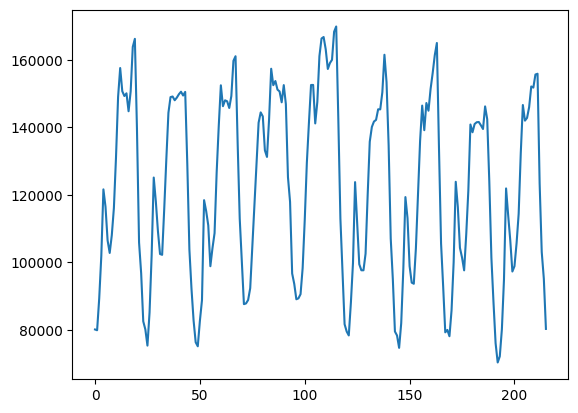

In [ ]:
df['y'].plot()

In [ ]:
train, test = df[:-24], df[-24:]

In [ ]:
m = Prophet()
m.fit(train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbnl638fy/c8ngvu2g.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbnl638fy/xu94c7fd.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93461', 'data', 'file=/tmp/tmpbnl638fy/c8ngvu2g.json', 'init=/tmp/tmpbnl638fy/xu94c7fd.json', 'output', 'file=/tmp/tmpbnl638fy/prophet_modelkjvbue3d/prophet_model-20250219080508.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
08:05:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:05:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = m.make_future_dataframe(periods = 24,freq='h')

In [ ]:
future

,ds
0,2017-09-13 00:00:00
1,2017-09-13 01:00:00
2,2017-09-13 02:00:00
3,2017-09-13 03:00:00
4,2017-09-13 04:00:00
...,...
211,2017-09-21 19:00:00
212,2017-09-21 20:00:00
213,2017-09-21 21:00:00
214,2017-09-21 22:00:00


In [ ]:
#making forecast
forecast = m.predict(future)

In [ ]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-09-13 00:00:00,120897.951700,64557.907886,87193.128868,120897.951700,120897.951700,-44893.118740,-44893.118740,-44893.118740,-44893.118740,-44893.118740,-44893.118740,0.0,0.0,0.0,76004.832960
1,2017-09-13 01:00:00,120956.316086,67354.636117,90217.009367,120956.316086,120956.316086,-42112.506472,-42112.506472,-42112.506472,-42112.506472,-42112.506472,-42112.506472,0.0,0.0,0.0,78843.809614
2,2017-09-13 02:00:00,121014.680472,76682.820242,98701.705587,121014.680472,121014.680472,-33201.426320,-33201.426320,-33201.426320,-33201.426320,-33201.426320,-33201.426320,0.0,0.0,0.0,87813.254152
3,2017-09-13 03:00:00,121073.044858,89099.680822,111246.650154,121073.044858,121073.044858,-20916.498678,-20916.498678,-20916.498678,-20916.498678,-20916.498678,-20916.498678,0.0,0.0,0.0,100156.546180
4,2017-09-13 04:00:00,121131.409244,99460.646274,122423.631209,121131.409244,121131.409244,-9673.130658,-9673.130658,-9673.130658,-9673.130658,-9673.130658,-9673.130658,0.0,0.0,0.0,111458.278587


We will plot the resulst of the forecast

We draw a vertical line marking the future

Note past this line there are no datapoints (black dots)

In [ ]:
# plot the results
import matplotlib.pyplot as plt

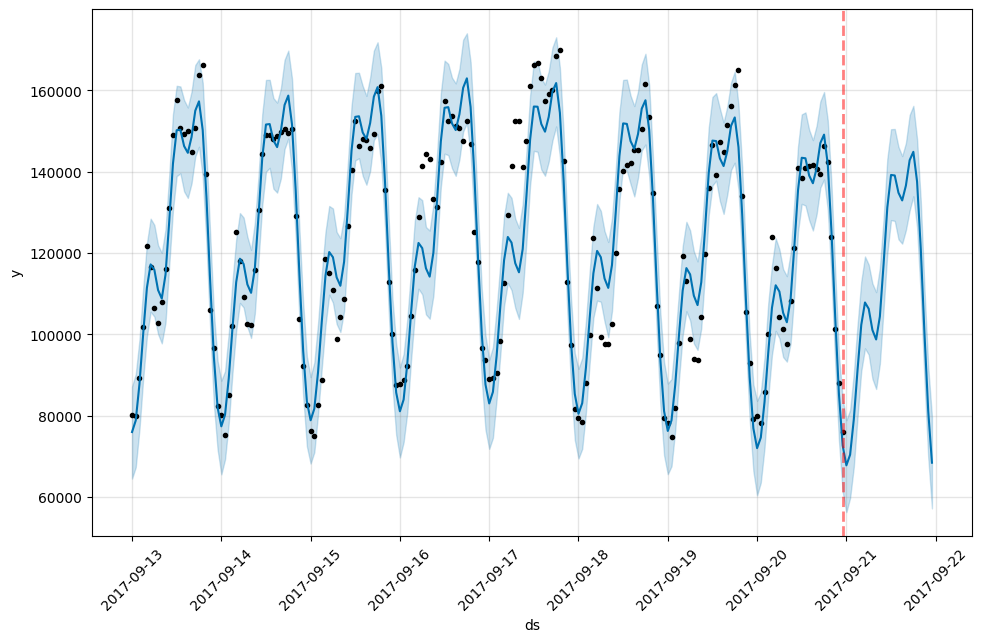

In [ ]:
m.plot(forecast)
plt.axvline(x = forecast['ds'].max() - pd.Timedelta('24 hours'),
            c='red', lw=2, alpha = .5, ls='--')
plt.xticks(rotation = 45)
plt.show()

* Black dots are given datapoins
* Blue lines are the forecast
* Shaded area - confidence interval
* Vertical line marks future values

In [ ]:
df.head()

,ds,y
0,2017-09-13 00:00:00,80115
1,2017-09-13 01:00:00,79885
2,2017-09-13 02:00:00,89325
3,2017-09-13 03:00:00,101930
4,2017-09-13 04:00:00,121630


Cross-validation
---

In [ ]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

In [ ]:
df_cv = cross_validation(
    m,
    horizon="24h",  # Forecasting 24 hours ahead
    period="12h",  # Frequency of evaluation (adjustable)
    initial="144"  # Initial training period (7 days = 168 hours)
)

INFO:prophet:Making 14 forecasts with cutoffs between 2017-09-13 11:00:00 and 2017-09-19 23:00:00


  0%|          | 0/14 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 8.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbnl638fy/uufi15mi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbnl638fy/8f89vts1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91093', 'data', 'file=/tmp/tmpbnl638fy/uufi15mi.json', 'init=/tmp/tmpbnl638fy/8f89vts1.json', 'output', 'file=/tmp/tmpbnl638fy/prophet_model8n3c90t4/prophet_model-20250219080605.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:06:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:06:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 18.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbnl638fy/ktlurv_v.json
DEBUG:cmdstanpy:input tempfil

In [ ]:
df_p = performance_metrics(df_cv)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,0 days 03:00:00,8.613410e+08,29348.612085,11220.238984,0.091734,0.055084,0.118767,0.673160
1,0 days 04:00:00,6.809817e+09,82521.612409,24503.867736,0.178242,0.057103,0.175981,0.612554
2,0 days 05:00:00,2.655592e+10,162959.886059,46596.461580,0.327923,0.065924,0.198570,0.532468
3,0 days 06:00:00,6.475686e+10,254473.685338,72588.637484,0.496789,0.047640,0.198889,0.530303
4,0 days 07:00:00,1.083701e+11,329196.073216,96364.783256,0.629816,0.046871,0.214724,0.469697
5,0 days 08:00:00,1.296532e+11,360073.948380,108834.685882,0.687691,0.097388,0.239856,0.419913
6,0 days 09:00:00,1.127530e+11,335787.067224,103424.239917,0.687649,0.099376,0.254692,0.387446
7,0 days 10:00:00,7.250881e+10,269274.593164,82349.411944,0.637394,0.068372,0.242750,0.428571
8,0 days 11:00:00,3.613229e+10,190084.963386,57661.137311,0.524492,0.056354,0.222654,0.478355
9,0 days 12:00:00,1.559726e+10,124888.980972,39508.028803,0.409819,0.053333,0.214205,0.530303


/usr/local/lib/python3.11/dist-packages/prophet/plot.py:546: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/usr/local/lib/python3.11/dist-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



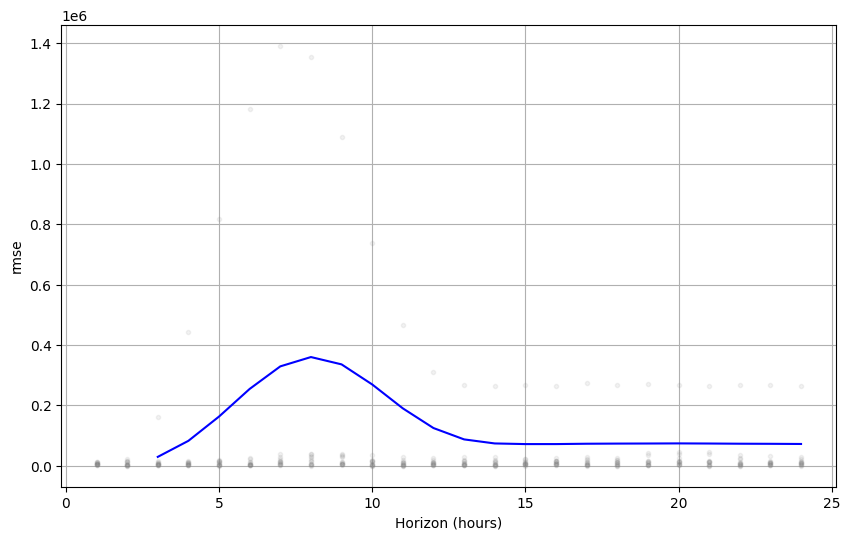

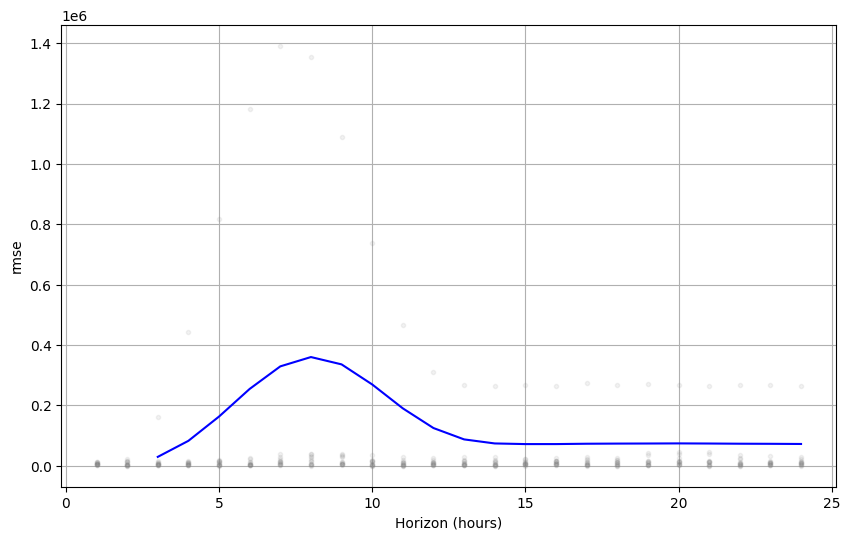

In [ ]:
from prophet.plot import plot_cross_validation_metric

plot_cross_validation_metric(df_cv, metric='rmse')

In [ ]:
df_p.mean()

,0
horizon,0 days 13:30:00
mse,29098723968.536839
rmse,137655.011901
mae,45247.679037
mape,0.364467
mdape,0.068692
smape,0.218553
coverage,0.465762
